In [2]:
# Import required packages
import torch
from torch import nn
from torch.distributions import Uniform
import numpy as np
import normflows as nf

from matplotlib import pyplot as plt

from tqdm import tqdm

In [3]:
period = 4
t = torch.arange(32)
wave = ((t % period) >= (period / 2))

torch.Size([5, 64])


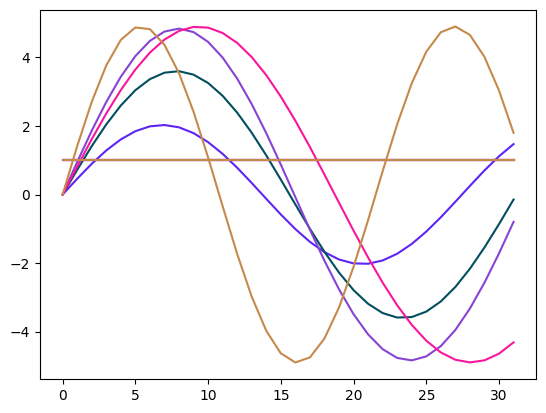

In [4]:
class SinDataset:
    def __init__(self, amplitude_range, frequency_range, horizon):
        self.amplitude_range = amplitude_range
        self.frequency_range = frequency_range
        self.horizon = horizon
        
        self.amplitude_dist = Uniform(amplitude_range[0], amplitude_range[1])
        self.frequency_dist = Uniform(frequency_range[0], frequency_range[1])
        
        self.sz = 10_000
        self.samples = self._sample(self.sz)
    
    def sample(self, n_samples):
        inds = torch.randint(0, self.sz, (n_samples,))
        return self.samples[inds, :]
    
    def _sample(self, n_samples):
        dt = 0.1
        ts_integer = torch.arange(0, self.horizon, 1).reshape(1, -1)
        ts_integer = torch.tile(ts_integer, (n_samples, 1))
        ts_float = ts_integer.float() * dt
                
        amplitudes = self.amplitude_dist.sample((n_samples, 1))
        frequencies = self.frequency_dist.sample((n_samples, 1))
        
        X = (torch.sin(2 * torch.pi * frequencies * ts_float) * amplitudes)
        # return X
        
        X = X.unsqueeze(-1)
        
        # period = self.horizon // 8
        # Y = ((ts_integer % period) >= (period // 2)).float()
        # Y = (Y * 2.0) - 1.0
        # Y = Y * amplitudes
        # Y = Y.unsqueeze(-1)
        Y = torch.ones_like(X)
        
        Z = torch.cat([X, Y], dim=-1)
        return Z.view(n_samples, 2 * self.horizon)

ds = SinDataset([0.5, 5.0], [0.1, 0.5], 32)
Z = ds.sample(5)
print(Z.shape)

for i in range(5):
    X = Z[i, 0::2]
    Y = Z[i, 1::2]
    # pick a random color
    # X = Z[i, :]
    color = np.random.rand(3,)
    
    plt.plot(X.numpy(), color=color)
    plt.plot(Y.numpy(), color=color)
    

In [7]:
n_channels = 2
horizon = 32
d = n_channels * horizon

base = nf.distributions.base.DiagGaussian(d)

# Define list of flows
b = torch.Tensor([1 if i % 2 == 0 else 0 for i in range(d)])
num_layers = 32
flows = []
for i in range(num_layers):
    s = nf.nets.MLP([d, 16, 16, d], init_zeros=True)
    t = nf.nets.MLP([d, 16, 16, d], init_zeros=False)
    
    if i % 2 == 0:
        flows += [nf.flows.MaskedAffineFlow(b, t, s)]
    else:
        flows += [nf.flows.MaskedAffineFlow(1 - b, t, s)]
    
# Set target and base distribution
q0 = nf.distributions.DiagGaussian(d)
model = nf.NormalizingFlow(q0=q0, flows=flows)
target = SinDataset([0.5, 5.0], [0.1, 0.3], horizon=horizon)

x = torch.randn(32, d)
z = model.inverse(x)
xrecon = model.forward(z)

assert torch.allclose(x, xrecon, atol=1e-5)

In [266]:
# Move model on GPU if available
enable_cuda = True
device = torch.device('cuda' if torch.cuda.is_available() and enable_cuda else 'cpu')
model = model.to(device)

# Print number of params in model
print(f"Number of parameters in the model: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Number of parameters in the model: 153728


  0%|          | 3/6000 [00:00<05:34, 17.95it/s]

Iter 1/6000, Loss: 159.87193298339844


  8%|▊         | 508/6000 [00:14<02:18, 39.73it/s]

Iter 501/6000, Loss: -104.87655639648438


 17%|█▋        | 1005/6000 [00:28<02:02, 40.85it/s]

...

 83%|████████▎ | 5007/6000 [02:34<00:27, 36.59it/s]

Iter 5001/6000, Loss: -212.81289672851562


 92%|█████████▏| 5504/6000 [02:51<00:14, 35.21it/s]

Iter 5501/6000, Loss: -247.15773010253906


100%|██████████| 6000/6000 [03:06<00:00, 32.18it/s]


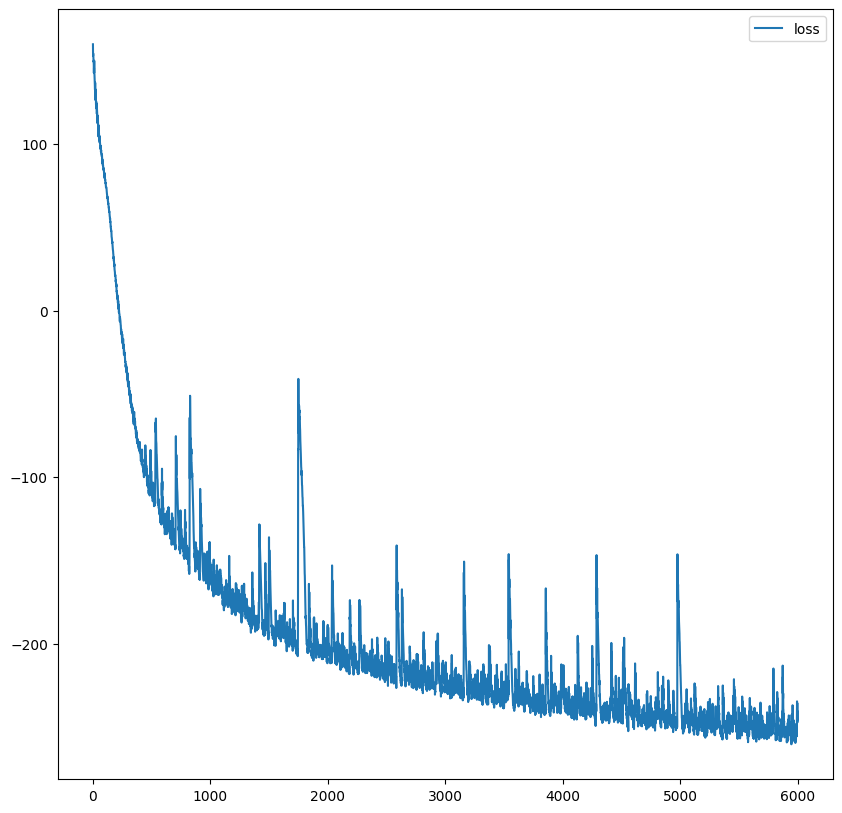

In [255]:
# Train model
max_iter = 6000
num_samples = 256
show_iter = 500

loss_hist = np.array([])

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

for it in tqdm(range(max_iter)):
    optimizer.zero_grad()
    
    # Get training samples
    x = target.sample(num_samples).to(device)
    
    # Compute loss
    loss = model.forward_kld(x)
    
    # Do backprop and optimizer step
    if ~(torch.isnan(loss) | torch.isinf(loss)):
        loss.backward()
        optimizer.step()
    
    # Log loss
    loss_hist = np.append(loss_hist, loss.to('cpu').data.numpy())
    
    # Plot learned distribution
    if (it) % show_iter == 0:
        print(f'Iter {it + 1}/{max_iter}, Loss: {loss_hist[-1]}')
        # model.eval()
        # log_prob = model.log_prob(zz)
        # model.train()
        # prob = torch.exp(log_prob.to('cpu').view(*xx.shape))
        # prob[torch.isnan(prob)] = 0

        # plt.figure(figsize=(15, 15))
        # plt.pcolormesh(xx, yy, prob.data.numpy(), cmap='coolwarm')
        # plt.gca().set_aspect('equal', 'box')
        # plt.show()

# Plot loss
plt.figure(figsize=(10, 10))
plt.plot(loss_hist, label='loss')
plt.legend()
plt.show()

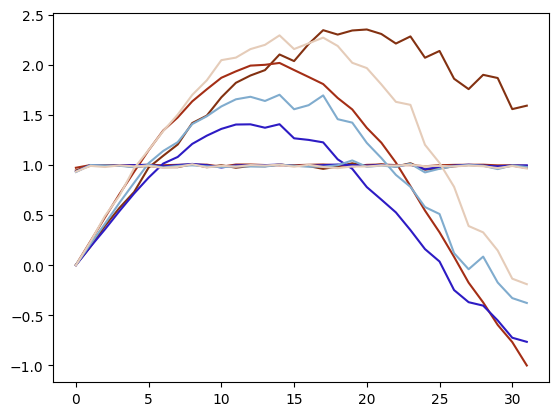

In [261]:
model_samples = model.sample(num_samples=5)
samples, _ = model_samples

for i in range(samples.shape[0]):
    # color = np.random.rand(3,)
    # ch1 = samples[i, :]
    # plt.plot(ch1.cpu().detach().numpy(), color=color)
    
    color = np.random.rand(3,)
    ch1 = samples[i, 0::2]
    ch2 = samples[i, 1::2]
    
    plt.plot(ch1.cpu().detach().numpy(), color=color)
    plt.plot(ch2.cpu().detach().numpy(), color=color)

plt.show()

In [23]:
b = 32
n_channels = 3
seq_len = 128

z = torch.randn(b, n_channels, seq_len)
z1, z2 = z.chunk(2, dim=1)

print(z1.shape, z2.shape)

ksize = 3
conv = nn.Conv1d(z1.shape[1], z2.shape[1], 3, padding=ksize//2)

scale = conv(z1)
print(scale.shape)

torch.Size([32, 2, 128]) torch.Size([32, 1, 128])
torch.Size([32, 1, 128])


In [70]:
class SqueezeTemporal(nf.flows.Flow):
    """
    Squeeze operation for temporal (1D) data.
    
    Forward:
      Input:  (B, C, T)  with C divisible by 2.
      Process:
        - Reshape to (B, C//2, 2, T)
        - Permute to (B, C//2, T, 2)
        - Reshape to (B, C//2, 2T)
      Output: (B, C//2, 2T)
    
    Inverse:
      Input:  (B, C, T)  where T is even (and here C = original C//2).
      Process:
        - Reshape to (B, C, T//2, 2)
        - Permute to (B, C, 2, T//2)
        - Reshape to (B, 2C, T//2)
      Output: (B, 2C, T//2)
      
    Note: The log-determinant for a squeeze/unsqueeze operation is zero.
    """
    
    def __init__(self):
        super().__init__()
    
    def forward(self, z):
        """
        Forward squeeze.
        
        Args:
            z (Tensor): Input tensor of shape (B, C, T) with C divisible by 2.
            
        Returns:
            z (Tensor): Squeezed tensor of shape (B, C//2, 2T).
            log_det (float): Zero (squeeze is volume preserving).
        """
        log_det = 0
        B, C, T = z.size()
        # Reshape to split the channel dimension into two parts:
        # (B, C, T) -> (B, C//2, 2, T)
        z = z.view(B, C // 2, 2, T)
        # Permute to bring the factor of 2 into the time dimension:
        # (B, C//2, 2, T) -> (B, C//2, T, 2)
        z = z.permute(0, 1, 3, 2).contiguous()
        # Merge the last two dimensions:
        # (B, C//2, T, 2) -> (B, C//2, 2T)
        z = z.view(B, C // 2, T * 2)
        return z, log_det

    def inverse(self, z):
        """
        Inverse squeeze (unsqueeze).
        
        Args:
            z (Tensor): Input tensor of shape (B, C, T) where T is even.
                        Here C corresponds to the squeezed channels (original C//2).
                        
        Returns:
            z (Tensor): Unsqueezed tensor of shape (B, 2C, T//2).
            log_det (float): Zero (unsqueeze is volume preserving).
        """
        log_det = 0
        B, C, T = z.size()  # Here, T is assumed to be even (T = 2 * original T)
        # Reshape to separate the temporal factor:
        # (B, C, T) -> (B, C, T//2, 2)
        z = z.view(B, C, T // 2, 2)
        # Permute to move the factor into the channel dimension:
        # (B, C, T//2, 2) -> (B, C, 2, T//2)
        z = z.permute(0, 1, 3, 2).contiguous()
        # Merge the channel factor:
        # (B, C, 2, T//2) -> (B, 2C, T//2)
        z = z.view(B, C * 2, T // 2)
        return z, log_det

In [71]:
def batchify(x, batch_size):
    x = torch.tile(x.unsqueeze(0), (batch_size, *((1,) * x.dim())))
    return x

x = batchify(torch.arange(10), 3) + 1
x = x.unsqueeze(1)

squeeze = SqueezeTemporal()
y, _ = squeeze.inverse(x)
z, _ = squeeze.forward(y)

print(x.shape)
print(y.shape)
print(z.shape)

assert torch.allclose(x, z)

torch.Size([3, 1, 10])
torch.Size([3, 2, 5])
torch.Size([3, 1, 10])


In [ ]:
n_channels = 3
horizon = 32
batch_size = 8
enc_dim = 32
context = torch.randn(batch_size, enc_dim)
ksize = 5
shape = (n_channels, horizon)

context_encoder = nn.Linear(enc_dim, n_channels * 2)
encoder_output = context_encoder(context)

print(encoder_output.shape)

eps = torch.randn(
    (batch_size,) + shape
)

split_ind = encoder_output.shape[-1] // 2
mean = encoder_output[..., :split_ind]
log_scale = encoder_output[..., split_ind:]

print(eps.shape)
print(mean.shape)
print(log_scale.shape)

mean = torch.unsqueeze(mean, dim=-1)
log_scale = torch.unsqueeze(log_scale, dim=-1)
mean = 17.7 * torch.ones_like(mean)
log_scale = torch.zeros_like(log_scale)

print(mean.shape)
print(log_scale.shape)

z = mean + torch.exp(log_scale) * eps

# dist = nf.distributions.base.ConditionalDiagGaussian((horizon, n_channels), context_encoder)
# sample, _ = dist.forward(10, context)
# print(sample.shape)

torch.Size([8, 6])
torch.Size([8, 3, 32])
torch.Size([8, 3])
torch.Size([8, 3])
torch.Size([8, 3, 1])
torch.Size([8, 3, 1])
tensor([[18.1703, 17.7627, 18.5341, 18.6930, 18.2325, 18.6804, 17.7983, 17.2356,
         18.4133, 17.6478, 17.8119, 18.8851, 18.2582, 18.1251, 16.4173, 17.7989,
         18.3003, 17.9991, 20.2285, 19.5325, 16.9743, 17.3419, 17.3408, 18.5608,
         18.1215, 17.5243, 17.7269, 15.8911, 16.1280, 17.1162, 17.6931, 16.3414],
        [17.7074, 16.6864, 14.8426, 17.0478, 15.8622, 17.2328, 17.7267, 17.5871,
         17.2877, 17.6160, 16.2256, 15.9345, 18.2958, 18.5791, 18.5361, 17.3944,
         16.5131, 17.9440, 17.2582, 19.7249, 16.7612, 17.3889, 18.0329, 16.3577,
         17.8688, 17.6393, 18.2204, 16.0541, 18.5678, 19.7378, 15.4911, 18.4345],
        [18.5537, 20.5080, 17.4031, 16.9639, 16.9065, 18.4549, 16.8423, 17.6796,
         17.0780, 18.5575, 19.2059, 17.8931, 17.7366, 14.9588, 18.4870, 17.1948,
         18.0730, 16.6541, 16.7900, 18.9899, 17.6813, 16.5762, 1

In [50]:
from normflows.utils import masks
from normflows.flows import reshape

f = reshape.Split(mode="checkerboard")
t = torch.arange(16).reshape(1, 4, 4)
[z1, z2], _ = f(t)

print(z1)
print(z2)
print(t)

tensor([[[ 1,  3],
         [ 4,  6],
         [ 9, 11],
         [12, 14]]])
tensor([[[ 0,  2],
         [ 5,  7],
         [ 8, 10],
         [13, 15]]])
tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11],
         [12, 13, 14, 15]]])
